## tuning, final evaluation, saving and loading


In [1]:
import sys
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.db import get_engine, fetch_table
from src.config import FEATURE_COLS_NO_WIFI
from src.features import make_features

print("Project root:", project_root)

Project root: d:\OMEN-16\ML-Projects\airline-satisfaction-ml


In [2]:
engine = get_engine()
df = fetch_table(engine)

X = make_features(df)
y = (df["satisfaction"] == "Satisfied").astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_no_wifi = X_train[FEATURE_COLS_NO_WIFI]

print("X_train:", X_train.shape)
print("X_train_no_wifi:", X_train_no_wifi.shape)
print("Share satisfied in y_train:", round(y_train.mean(), 4))

X_train: (103904, 18)
X_train_no_wifi: (103904, 17)
Share satisfied in y_train: 0.4345


## Here are three models to tune

In [3]:
# preprocessing  (all three models are tree-based)
tree_prep = ColumnTransformer(
    [
        ("class_order", OrdinalEncoder(categories=[["Economy", "Economy Plus", "Business"]]), ["travel_class"]),
        ("two_labels", OrdinalEncoder(), ["customer_type", "type_of_travel"]),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)
tree_prep.set_output(transform="pandas")

lgbm = make_pipeline(clone(tree_prep), LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1))
xgb = make_pipeline(clone(tree_prep), XGBClassifier(random_state=42, n_jobs=-1))
forest = make_pipeline(clone(tree_prep), RandomForestClassifier(random_state=42, n_jobs=-1))

base_models = {
    "LightGBM": lgbm,
    "XGBoost": xgb,
    "Random Forest": forest,
}

print(list(base_models))

['LightGBM', 'XGBoost', 'Random Forest']


In [4]:
default_wifi = pd.read_csv("../reports/model_comparison_with_wifi.csv", index_col=0)
default_no_wifi = pd.read_csv("../reports/model_comparison_without_wifi.csv", index_col=0)

names = ["LightGBM", "XGBoost", "Random Forest"]

print("Default settings, with wifi:")
print(default_wifi.loc[names, ["accuracy", "f1", "roc_auc", "gap"]])
print()
print("Default settings, without wifi:")
print(default_no_wifi.loc[names, ["accuracy", "f1", "roc_auc", "gap"]])

Default settings, with wifi:
               accuracy     f1  roc_auc   gap
LightGBM          96.30  95.66    99.45  0.24
XGBoost           96.22  95.58    99.46  1.21
Random Forest     96.22  95.57    99.34  3.78

Default settings, without wifi:
               accuracy     f1  roc_auc   gap
LightGBM          94.16  93.17    98.56  0.35
XGBoost           94.16  93.16    98.56  1.87
Random Forest     94.12  93.12    98.43  5.88


In [5]:
# the same 5 folds as Step 10
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# here these are settings to try, the pipeline step name comes first, then two underscores
spaces = {
    "LightGBM": {
        "lgbmclassifier__n_estimators": [100, 200, 300, 400],
        "lgbmclassifier__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "lgbmclassifier__num_leaves": [15, 31, 63, 127],
        "lgbmclassifier__min_child_samples": [10, 20, 40],
        "lgbmclassifier__colsample_bytree": [0.6, 0.8, 1.0],
    },
    "XGBoost": {
        "xgbclassifier__n_estimators": [100, 200, 300, 400],
        "xgbclassifier__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "xgbclassifier__max_depth": [4, 6, 8, 10],
        "xgbclassifier__min_child_weight": [1, 3, 5],
        "xgbclassifier__colsample_bytree": [0.6, 0.8, 1.0],
    },
    "Random Forest": {
        "randomforestclassifier__n_estimators": [100, 200],
        "randomforestclassifier__max_depth": [10, 15, 20, 30],
        "randomforestclassifier__min_samples_leaf": [1, 3, 5, 10],
        "randomforestclassifier__max_features": ["sqrt", 0.5],
    },
}

# these are the random combinations to try for each model
tries = {"LightGBM": 12, "XGBoost": 12, "Random Forest": 8}

for name in spaces:
    combos = 1
    for values in spaces[name].values():
        combos = combos * len(values)
    print(name.ljust(15), combos, "possible combinations, we try", tries[name])

LightGBM        576 possible combinations, we try 12
XGBoost         576 possible combinations, we try 12
Random Forest   64 possible combinations, we try 8


#### Running the searches with wifi

In [6]:
searches = {}

for name in base_models:
    start = time.time()

    search = RandomizedSearchCV(base_models[name], spaces[name], n_iter=tries[name],
                                scoring="f1", cv=cv, random_state=42)
    search.fit(X_train, y_train)

    searches[name] = search
    print(name.ljust(15), round(time.time() - start), "seconds | best F1:", round(search.best_score_ * 100, 2))

LightGBM        90 seconds | best F1: 95.93
XGBoost         52 seconds | best F1: 95.77
Random Forest   34 seconds | best F1: 95.66


In [7]:
for name in searches:
    scores = searches[name].cv_results_["mean_test_score"] * 100

    print(name)
    print("  F1 of the", len(scores), "combinations: worst", round(scores.min(), 2),
          "| middle", round(np.median(scores), 2), "| best", round(scores.max(), 2))
    print("  best settings:", searches[name].best_params_)
    print()

LightGBM
  F1 of the 12 combinations: worst 93.58 | middle 95.7 | best 95.93
  best settings: {'lgbmclassifier__num_leaves': 63, 'lgbmclassifier__n_estimators': 300, 'lgbmclassifier__min_child_samples': 40, 'lgbmclassifier__learning_rate': 0.03, 'lgbmclassifier__colsample_bytree': 0.8}

XGBoost
  F1 of the 12 combinations: worst 93.78 | middle 95.62 | best 95.77
  best settings: {'xgbclassifier__n_estimators': 300, 'xgbclassifier__min_child_weight': 3, 'xgbclassifier__max_depth': 10, 'xgbclassifier__learning_rate': 0.03, 'xgbclassifier__colsample_bytree': 0.8}

Random Forest
  F1 of the 8 combinations: worst 93.72 | middle 95.29 | best 95.66
  best settings: {'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__min_samples_leaf': 3, 'randomforestclassifier__max_features': 0.5, 'randomforestclassifier__max_depth': 30}



In [8]:
# score the three tuned models the same way as Step 10, so the numbers can be compared
tuned = {}

for name in searches:
    scores = cross_validate(searches[name].best_estimator_, X_train, y_train, cv=cv,
                            scoring=scoring, return_train_score=True)
    tuned[name] = pd.DataFrame(scores).mean()

tuned = pd.DataFrame(tuned).T

compare = pd.DataFrame({
    "f1 default": default_wifi.loc[names, "f1"],
    "f1 tuned": tuned["test_f1"] * 100,
    "accuracy tuned": tuned["test_accuracy"] * 100,
    "roc_auc tuned": tuned["test_roc_auc"] * 100,
    "gap default": default_wifi.loc[names, "gap"],
    "gap tuned": (tuned["train_accuracy"] - tuned["test_accuracy"]) * 100,
})
compare["f1 change"] = compare["f1 tuned"] - compare["f1 default"]

compare.round(2)

,f1 default,f1 tuned,accuracy tuned,roc_auc tuned,gap default,gap tuned,f1 change
LightGBM,95.66,95.93,96.53,99.51,0.24,0.45,0.27
XGBoost,95.58,95.77,96.39,99.48,1.21,1.08,0.19
Random Forest,95.57,95.66,96.29,99.41,3.78,2.51,0.09


#### Running the search without wifi

In [9]:
searches_no_wifi = {}

for name in base_models:
    start = time.time()

    search = RandomizedSearchCV(base_models[name], spaces[name], n_iter=tries[name],
                                scoring="f1", cv=cv, random_state=42)
    search.fit(X_train_no_wifi, y_train)

    searches_no_wifi[name] = search
    print(name.ljust(15), round(time.time() - start), "seconds | best F1:", round(search.best_score_ * 100, 2))

LightGBM        52 seconds | best F1: 93.54
XGBoost         46 seconds | best F1: 93.5
Random Forest   39 seconds | best F1: 93.35


In [10]:
for name in searches_no_wifi:
    scores = searches_no_wifi[name].cv_results_["mean_test_score"] * 100

    print(name)
    print("  F1 of the", len(scores), "combinations: worst", round(scores.min(), 2),
          "| middle", round(np.median(scores), 2), "| best", round(scores.max(), 2))
    print("  best settings:", searches_no_wifi[name].best_params_)
    print()

LightGBM
  F1 of the 12 combinations: worst 90.86 | middle 93.34 | best 93.54
  best settings: {'lgbmclassifier__num_leaves': 127, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__min_child_samples': 20, 'lgbmclassifier__learning_rate': 0.05, 'lgbmclassifier__colsample_bytree': 0.8}

XGBoost
  F1 of the 12 combinations: worst 91.77 | middle 93.26 | best 93.5
  best settings: {'xgbclassifier__n_estimators': 300, 'xgbclassifier__min_child_weight': 3, 'xgbclassifier__max_depth': 10, 'xgbclassifier__learning_rate': 0.03, 'xgbclassifier__colsample_bytree': 0.8}

Random Forest
  F1 of the 8 combinations: worst 91.77 | middle 92.95 | best 93.35
  best settings: {'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__min_samples_leaf': 3, 'randomforestclassifier__max_features': 0.5, 'randomforestclassifier__max_depth': 30}



In [11]:
tuned_nw = {}

for name in searches_no_wifi:
    scores = cross_validate(searches_no_wifi[name].best_estimator_, X_train_no_wifi, y_train, cv=cv,
                            scoring=scoring, return_train_score=True)
    tuned_nw[name] = pd.DataFrame(scores).mean()

tuned_nw = pd.DataFrame(tuned_nw).T

compare_nw = pd.DataFrame({
    "f1 default": default_no_wifi.loc[names, "f1"],
    "f1 tuned": tuned_nw["test_f1"] * 100,
    "accuracy tuned": tuned_nw["test_accuracy"] * 100,
    "roc_auc tuned": tuned_nw["test_roc_auc"] * 100,
    "gap default": default_no_wifi.loc[names, "gap"],
    "gap tuned": (tuned_nw["train_accuracy"] - tuned_nw["test_accuracy"]) * 100,
})
compare_nw["f1 change"] = compare_nw["f1 tuned"] - compare_nw["f1 default"]

compare_nw.round(2)

,f1 default,f1 tuned,accuracy tuned,roc_auc tuned,gap default,gap tuned,f1 change
LightGBM,93.17,93.54,94.49,98.67,0.35,0.68,0.37
XGBoost,93.16,93.50,94.46,98.67,1.87,2.05,0.34
Random Forest,93.12,93.35,94.33,98.51,5.88,3.49,0.23


#### Before and After charts

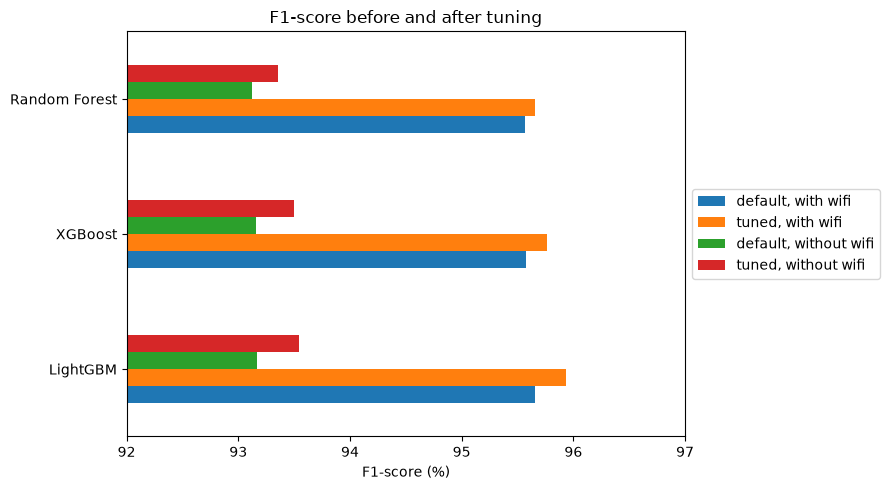

In [12]:
chart = pd.DataFrame({
    "default, with wifi": compare["f1 default"],
    "tuned, with wifi": compare["f1 tuned"],
    "default, without wifi": compare_nw["f1 default"],
    "tuned, without wifi": compare_nw["f1 tuned"],
})

chart.plot(kind="barh", figsize=(9, 5))

plt.title("F1-score before and after tuning")
plt.xlabel("F1-score (%)")
plt.xlim(92, 97)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig("../reports/figures/25_tuning_f1.png", dpi=120, bbox_inches="tight")
plt.show()

observation:
- Here for each model, the tuned bar is a little longer than the default bar, in both the with-wifi and the without-wifi pair. LightGBM has the longest bars.

#### Choosing the best model

In [13]:
best_name = compare["f1 tuned"].idxmax()
best_name_no_wifi = compare_nw["f1 tuned"].idxmax()

best_model = searches[best_name].best_estimator_
best_model_no_wifi = searches_no_wifi[best_name_no_wifi].best_estimator_

print("Best model with wifi   :", best_name, "| F1", round(compare.loc[best_name, "f1 tuned"], 2))
print("Best model without wifi:", best_name_no_wifi, "| F1", round(compare_nw.loc[best_name_no_wifi, "f1 tuned"], 2))

Best model with wifi   : LightGBM | F1 95.93
Best model without wifi: LightGBM | F1 93.54


In [14]:
best_settings = {"with_wifi": {}, "without_wifi": {}}

for name in searches:
    best_settings["with_wifi"][name] = searches[name].best_params_
    best_settings["without_wifi"][name] = searches_no_wifi[name].best_params_

with open("../models/best_settings.json", "w") as file:
    json.dump(best_settings, file, indent=2)

compare.round(2).to_csv("../reports/tuning_with_wifi.csv")
compare_nw.round(2).to_csv("../reports/tuning_without_wifi.csv")

print("Saved the best settings and two tuning tables")

Saved the best settings and two tuning tables
